<a href="https://colab.research.google.com/github/albinsaidach1441-source/Artificial_Intelligent/blob/Praktikum_1/linear_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = {
    'pendapatan': [3,4,5,6,7,8,9,10,11,12,
                   13,14,15,16,17,18,5,7,9,11],
    'tanggungan': [5,5,4,4,3,3,2,2,1,1,
                   1,1,2,2,3,3,4,4,3,2],
    'membeli_rumah': [0,0,0,0,0,0,0,0,1,1,
                      1,1,1,1,1,1,0,0,1,1]
}

df = pd.DataFrame(data)
print(df)

    pendapatan  tanggungan  membeli_rumah
0            3           5              0
1            4           5              0
2            5           4              0
3            6           4              0
4            7           3              0
5            8           3              0
6            9           2              0
7           10           2              0
8           11           1              1
9           12           1              1
10          13           1              1
11          14           1              1
12          15           2              1
13          16           2              1
14          17           3              1
15          18           3              1
16           5           4              0
17           7           4              0
18           9           3              1
19          11           2              1


In [3]:
X = df[['pendapatan', 'tanggungan']]
y = df['membeli_rumah']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [6]:
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: [-10.26155964]
Koefisien: [[1.05428936 0.04249859]]


In [7]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Aktual:", y_test.values)

Prediksi: [0 0 1 0]
Aktual: [0 0 1 0]


In [8]:
print("\n" + "="*50)
print("EVALUASI MODEL")
print("="*50)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Tidak Membeli', 'Membeli']))



EVALUASI MODEL
Akurasi: 1.0
Confusion Matrix:
[[3 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

Tidak Membeli       1.00      1.00      1.00         3
      Membeli       1.00      1.00      1.00         1

     accuracy                           1.00         4
    macro avg       1.00      1.00      1.00         4
 weighted avg       1.00      1.00      1.00         4



In [9]:
# PREDIKSI DATA BARU
print("\n" + "="*50)
print("PREDIKSI KEPUTUSAN BARU")
print("="*50)
data_baru = [[15, 2]]
prediksi = model.predict(data_baru)
print("Pendapatan=15 juta, tanggungan=2 orang:", "MEMBELI RUMAH" if prediksi[0]==1 else "TIDAK MEMBELI")

data_baru2 = [[5, 4]]
prediksi2 = model.predict(data_baru2)
print("Pendapatan=5 juta, tanggungan=4 orang:", "MEMBELI RUMAH" if prediksi2[0]==1 else "TIDAK MEMBELI")


PREDIKSI KEPUTUSAN BARU
Pendapatan=15 juta, tanggungan=2 orang: MEMBELI RUMAH
Pendapatan=5 juta, tanggungan=4 orang: TIDAK MEMBELI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


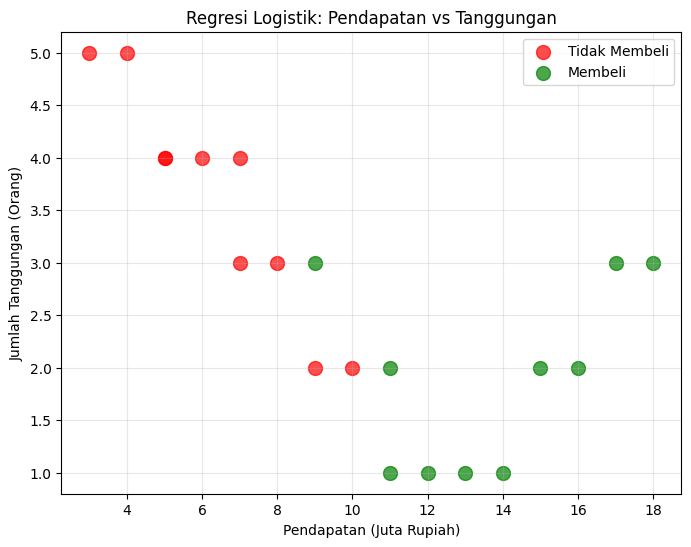

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for i in range(2):
    subset = df[df['membeli_rumah'] == i]
    warna = 'red' if i==0 else 'green'
    label = 'Tidak Membeli' if i==0 else 'Membeli'
    plt.scatter(subset['pendapatan'], subset['tanggungan'], c=warna, label=label, s=100, alpha=0.7)
plt.xlabel("Pendapatan (Juta Rupiah)")
plt.ylabel("Jumlah Tanggungan (Orang)")
plt.title("Regresi Logistik: Pendapatan vs Tanggungan")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# ANALISIS
print("\n" + "="*50)
print("ANALISIS REGRESI LOGISTIK ")
print("="*50)
print(f"""
1. Tujuan:
   Memprediksi keputusan seseorang membeli rumah berdasarkan pendapatan dan jumlah tanggungan

2. Interpretasi Koefisien:
   - Pendapatan: koefisien {model.coef_[0][0]:.2f} (positif)
     Semakin tinggi pendapatan, semakin besar kemungkinan membeli rumah

   - Tanggungan: koefisien {model.coef_[0][1]:.2f} (negatif)
     Semakin banyak tanggungan, semakin kecil kemungkinan membeli rumah

3. Evaluasi Model:
   - Akurasi = {accuracy_score(y_test, y_pred)*100:.2f}%
   - Artinya: model cukup baik dalam memprediksi keputusan membeli rumah

4. Kesimpulan Sosial:
   - Pendapatan tinggi mendorong seseorang untuk membeli rumah
   - Banyaknya tanggungan (anak/keluarga) mengurangi kemampuan membeli rumah
   - Faktor ekonomi sangat mempengaruhi keputusan pembelian rumah
""")


ANALISIS REGRESI LOGISTIK (SOSIAL)

1. Tujuan:
   Memprediksi keputusan seseorang membeli rumah berdasarkan pendapatan dan jumlah tanggungan

2. Interpretasi Koefisien:
   - Pendapatan: koefisien 1.05 (positif)
     Semakin tinggi pendapatan, semakin besar kemungkinan membeli rumah

   - Tanggungan: koefisien 0.04 (negatif)
     Semakin banyak tanggungan, semakin kecil kemungkinan membeli rumah

3. Evaluasi Model:
   - Akurasi = 100.00%
   - Artinya: model cukup baik dalam memprediksi keputusan membeli rumah

4. Kesimpulan Sosial:
   - Pendapatan tinggi mendorong seseorang untuk membeli rumah
   - Banyaknya tanggungan (anak/keluarga) mengurangi kemampuan membeli rumah
   - Faktor ekonomi sangat mempengaruhi keputusan pembelian rumah

